In [1]:
import numpy as np
import matplotlib.pyplot as plt

from py_wake.wind_farm_models import PropagateDownwind
from py_wake.deficit_models import BastankhahGaussianDeficit
from py_wake.superposition_models import LinearSum

from py_wake.flow_map import Points

from py_wake.wind_turbines._wind_turbines import WindTurbine, WindTurbines
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular
from py_wake import HorizontalGrid
from py_wake.site._site import UniformSite
from py_wake.site.shear import PowerShear

In [2]:
# Case constants

D = 100 # Rotor diameter [m]
zh = 100 # Hub height [m]

s = 10 # Turbine spacing [D]
x_turb_no = 10  # No. of turbines in streamwise direction [-]
y_turb_no = 7 # No. of turbines in transverse direction [-]

ws = 10 # Wind speed [m/s]
wd = 270 # Wind direction [deg]
ti0 = np.mean([0.09, 0.1, 0.11, 0.12, 0.14, 0.15, 0.16, 0.17, 0.18]) # Turbulence intensity [-]

In [3]:
# Define wind turbine object

u = np.arange(0, 25.5, .5) # [m/s]

po = [0, 0, 0, 0, 5, 15, 37, 73, 122, 183, 259, 357, 477, 622, 791, 988, 1212, 1469, 1755, 2009, 2176, 2298, 2388, 2447, 2485, 2500, 2500, 2500,
      2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500, 2500,
      2500, 2500, 2500, 2500, 2500, 2500, 2500, 0] # [kW]
ct = 0.8 * np.ones_like([0, 0, 0, 0, 0.78, 0.77, 0.78, 0.78, 0.77, 0.77, 0.78, 0.78, 0.78, 0.78, 0.78, 0.78, 0.77, 0.77, 0.77, 0.76, 0.73, 0.7, 0.68, 0.52, 0.42,
      0.36, 0.31, 0.27, 0.24, 0.22, 0.19, 0.18, 0.16, 0.14, 0.13, 0.12, 0.11, 0.1, 0.09, 0.08, 0.08, 0.08, 0.07, 0.07, 0.06, 0.06, 0.06,
      0.05, 0.05, 0.05, 0.04, 0]) # [-]
      # 1 value for flow_map

wt1 = WindTurbine(name="Ørsted1", diameter=D, hub_height=zh, powerCtFunction=PowerCtTabular(u, po, 'kw', ct))

In [4]:
# Initialize flow model

y, x = [v.flatten().astype(int) for v in np.meshgrid(np.arange(y_turb_no) * D * s, np.arange(x_turb_no) * D * s)]

site = UniformSite(shear=PowerShear(h_ref=zh, alpha=.1))
wfm = PropagateDownwind(site, wt1, wake_deficitModel=BastankhahGaussianDeficit(use_effective_ws=True), superpositionModel=LinearSum())
sim = wfm(x, y, ws=ws, wd=wd, TI=ti0)

In [5]:
D_downstream = [120, 240, 360]  # Downstream distances [D]
m_downstream = [d * D for d in D_downstream]  # Measurement distances [m]

w_meas = 10000  # Measurement width [m]

# Generate y-values for measurement distances
y_meas = np.linspace(min(y) - w_meas, max(y) + w_meas, max(y) + 2 * w_meas, endpoint=False)
y_meas = np.tile(y_meas, (len(m_downstream), 1)).T  # Shape: (num_y_points, len(m_downstream))

ws_meas = np.zeros((y_meas.shape[0], len(m_downstream)))  # Preallocate for efficiency

ws_min = np.zeros(len(m_downstream))
ws_deficit_max = np.zeros(len(m_downstream))
y_plateau = []
y_wake = []
ws_wake = []

# Loop through each x-meas value (measurement x-position)
for i, m in enumerate(m_downstream):
    x_meas = np.full(y_meas.shape[0], max(x) + m)  # Repeat `max(x) + m` for each corresponding `y_meas` row
    
    ws_meas[:, i] = np.squeeze(
        sim.flow_map(Points(
            x=x_meas,               # Fixed x for this loop iteration
            y=y_meas[:, i],         # Extract y-values for this x-value
            h=zh * np.ones_like(y_meas[:, i])  # Same height for all
        )).WS_eff.values)

    ws_min[i] = np.min(ws_meas[:, i])  # Minimum wind speed for this x
    ws_deficit_max[i] = ws - ws_min[i]  # Maximum wind speed deficit
    y_plateau.append(y_meas[ws_meas[:, i] <= ws_min[i] + 0.1 * ws_deficit_max[i], i])

    y_wake.append(y_meas[np.round(ws_meas[:, i], 3) < ws, i])
    ws_wake.append(ws_meas[np.round(ws_meas[:, i], 3) < ws, i])

# Calculate the average wind speed only in the y_plateau interval
ws_meas_avg = np.array([np.mean(ws_meas[np.isin(y_meas[:, i], y_plateau[i]), i]) for i in range(len(m_downstream))])

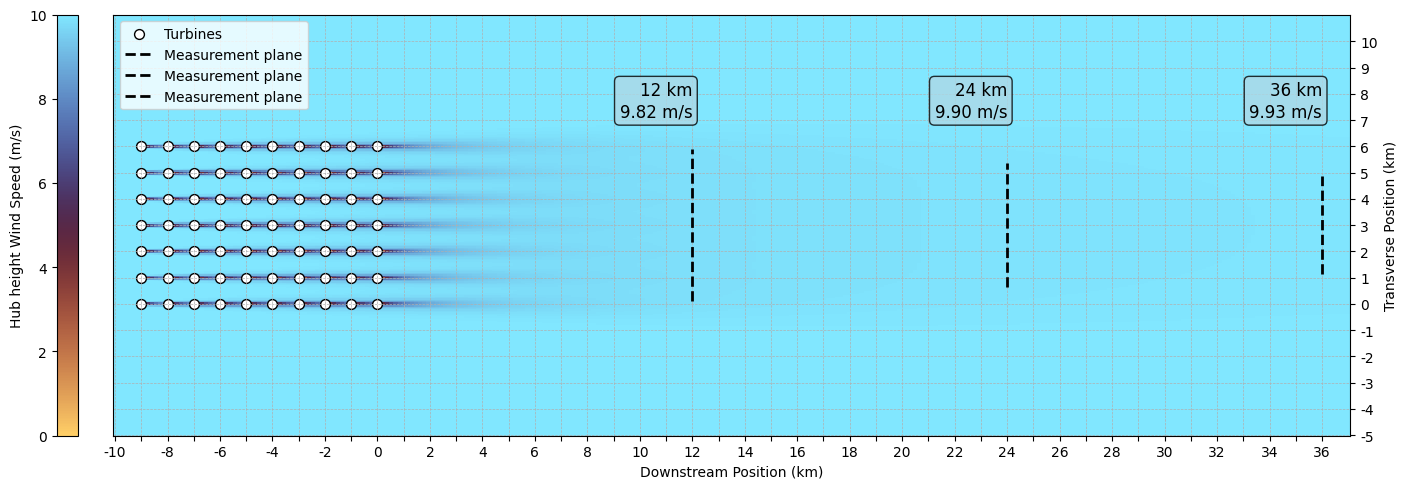

In [6]:
# Farm wake Visualization
fig, ax = plt.subplots(figsize=(18, 5))

ext_x = 1000
ext_y = 5000

# Compute the flow map and grid
flow_map_grid = HorizontalGrid(x=np.linspace(min(x)-ext_x, max(x)+m+ext_x, 300), y=np.linspace(min(y)-ext_y, max(y)+ext_y, 300))
flow_map = sim.flow_map(grid=flow_map_grid)
wake_map = flow_map.sel(wd=wd, ws=ws, method="nearest")

wake_map.WS_eff.plot(ax=ax, cmap="managua", vmin=0, vmax=ws, cbar_kwargs={'label': 'Hub height Wind Speed (m/s)', 'location': 'left', "pad": 0.02})

# Plot turbine positions
ax.scatter(x, y, color="white", marker="o", s=50, label="Turbines", edgecolor="black", linewidth=1)

# Plot measurement planes for each x_meas
for i, m in enumerate(m_downstream):
    x_meas = max(x) + m  # Measurement distance after farm
    ax.vlines(x=x_meas, ymin=min(y_plateau[i]), ymax=max(y_plateau[i]), color='black', linestyle='dashed', linewidth=2, label="Measurement plane")
    plt.text(x_meas, max(y) + 1000, f'{m/1000:.0f} km\n{ws_meas_avg[i]:.2f} m/s', 
             ha='right', va='bottom', fontsize=12, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

ax.set_title("")
ax.set_xlabel("Downstream Position (km)")
ax.set_ylabel("Transverse Position (km)")
ax.set_aspect('equal')
ax.legend(loc='upper left')

# Add axis labels, grid with ticklines
xticks = np.arange(max(x) - x_turb_no * s * D, max(x) + m + ext_x, 1000)
yticks = np.arange(min(y) - ext_y, max(y) + ext_y, 1000)

ax.set_xticks(xticks)
ax.set_xticklabels([f"{(val - max(x)) / 1000:.0f}" if i % 2 == 0 else "" for i, val in enumerate(xticks)])
ax.set_yticks(yticks)
ax.set_yticklabels([f"{val / 1000:.0f}" for val in yticks])

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()

plt.tight_layout()

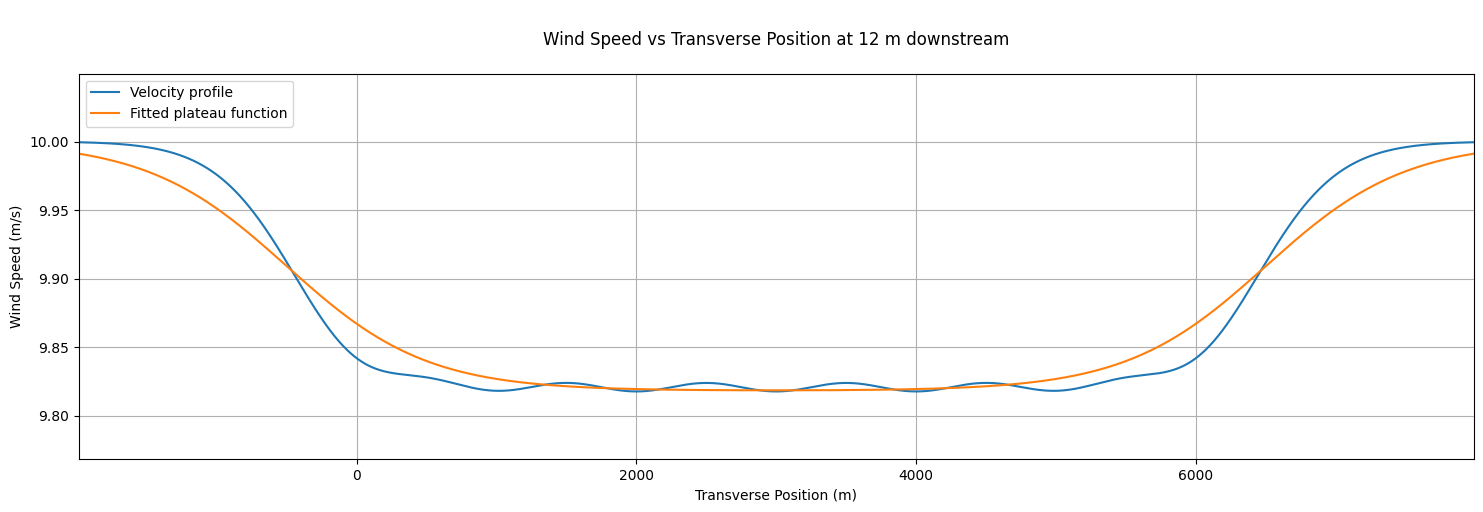

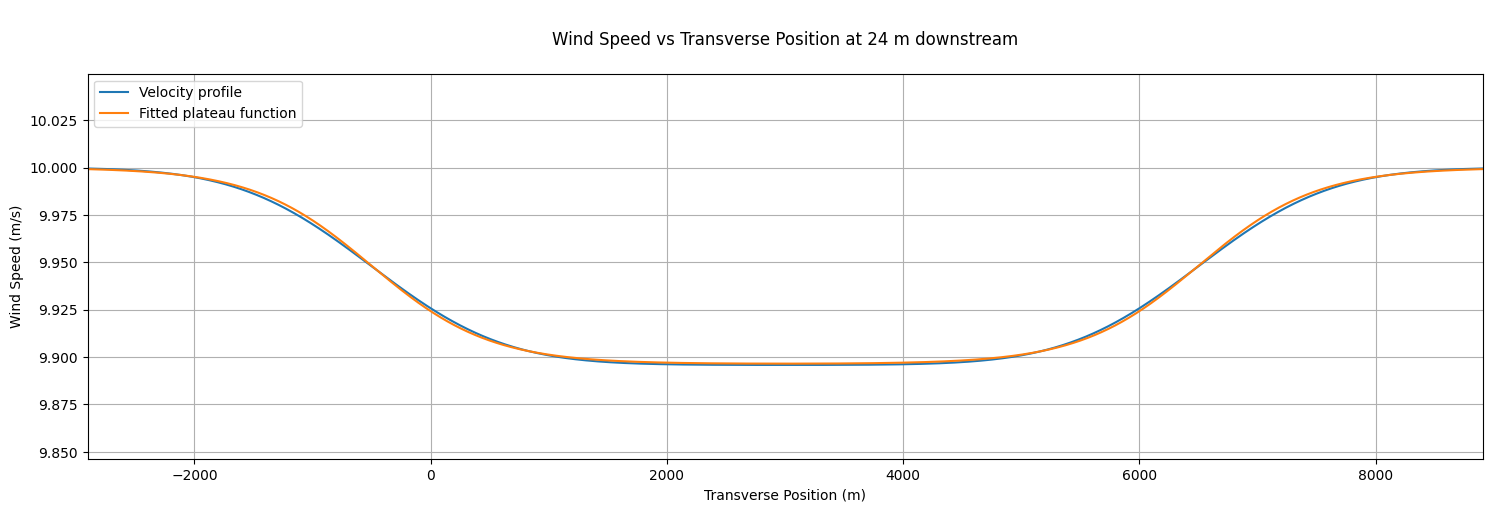

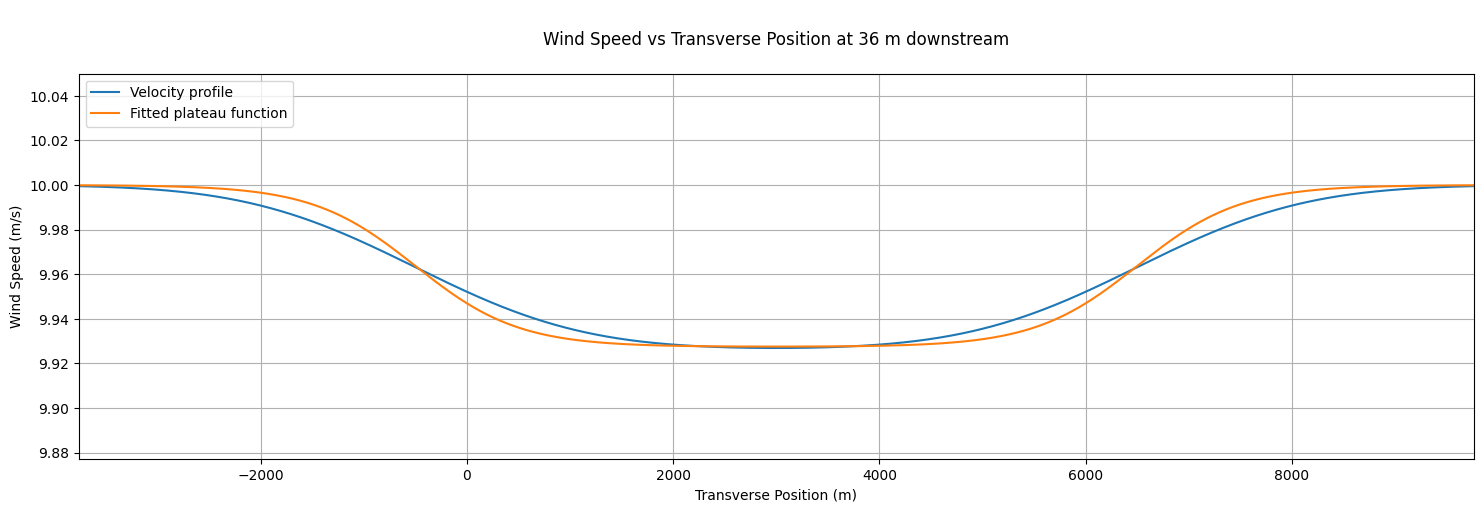

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Loop through each `i` in `m_downstream` for plotting
for i, m in enumerate(m_downstream):
    # Extract corresponding `y_wake` and `ws_wake` values for this iteration
    y_wake_i = y_wake[i]  # y_meas values where wind speed < 10
    ws_wake_i = ws_wake[i]  # Wind speed values where wind speed < 10

    plt.figure(figsize=(18, 5))
    
    # Plot the velocity profile (wake region)
    plt.plot(y_wake_i, ws_wake_i, label=f'Velocity profile')

    '''# Frandsen-based Gaussian kernel fit
    k = 0.04
    sigma = max(y) / 2 + k * x_meas
    U_max_def = ((ws - 9.81) * w_wake) / (np.sqrt(2 * np.pi) * sigma)
    U_y = U_max_def * np.exp(-(y_wake_i - np.median(y_wake_i)) ** 2 / (2 * sigma ** 2))
    plt.plot(y_wake_i, ws - U_y, label='Fitted Gaussian')
    '''

    # Plateau function fit (as in your previous code)
    p_w = 1.75 * 2000    # Wake width
    p_c = max(y) / 2     # Wake center
    p_s = 0.002          # Sharpness of transition
    A = max(ws_wake_i) - min(ws_wake_i)  # Scale to wake magnitude
    
    # Plateau function for wind speed deficit
    U_y = A * 1 / ((np.exp(p_s * (y_wake_i - p_c - p_w)) + 1) * (np.exp(p_s * (-y_wake_i + p_c - p_w)) + 1))

    # Plot fitted Plateau function
    plt.plot(y_wake_i, ws - U_y, label='Fitted plateau function')

    # Plot labels and title
    plt.xlabel('Transverse Position (m)')
    plt.ylabel('Wind Speed (m/s)')

    # Adjust plot limits for better visualization
    plt.xlim(min(y_wake_i), max(y_wake_i))
    plt.ylim(0.995 * min(min(ws_wake_i), min(ws - U_y)), 1.005 * max(max(ws_wake_i), max(ws - U_y)))

    plt.title(f'\nWind Speed vs Transverse Position at {m/1000:.0f} m downstream\n')
    plt.legend(loc="upper left")
    plt.grid(True)
    
    # Show the plot
    plt.show()